In [8]:
# Upload kaggle.json when prompted
from google.colab import files
files.upload()  # select your kaggle.json file here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"swastik89","key":"1a4e97ebb03e624f2297c0f17db32e05"}'}

In [9]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle API configured.")

Kaggle API configured.


In [10]:
# Primary: Tox21
!kaggle datasets download -d epicskills/tox21-dataset --unzip -p /content/tox21/

# Secondary: ZINC250k
!kaggle datasets download -d basu369victor/zinc250k --unzip -p /content/zinc250k/

Dataset URL: https://www.kaggle.com/datasets/epicskills/tox21-dataset
License(s): DbCL-1.0
100% 126k/126k [00:00<00:00, 62.3MB/s]

Dataset URL: https://www.kaggle.com/datasets/basu369victor/zinc250k
License(s): DbCL-1.0
100% 8.60M/8.60M [00:00<00:00, 65.1MB/s]



In [11]:
import os

print("Tox21 files:")
for f in os.listdir('/content/tox21/'):
    print(" ", f)

print("\nZINC250k files:")
for f in os.listdir('/content/zinc250k/'):
    print(" ", f)

Tox21 files:
  tox21.csv

ZINC250k files:
  250k_rndm_zinc_drugs_clean_3.csv


In [12]:
#Cell — Installs
!pip install rdkit -q
!pip install deepchem -q
!pip install imbalanced-learn -q

In [13]:
#Cell — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw, AllChem
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print("All imports successful.")

All imports successful.


In [14]:
#Cell — Load Tox21
tox21_df = pd.read_csv('/content/tox21/tox21.csv')
print("Shape:", tox21_df.shape)
print("Columns:", list(tox21_df.columns))
tox21_df.head()

Shape: (7831, 14)
Columns: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'mol_id', 'smiles']


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [15]:
#Cell — Define assay columns
assay_cols = ['NR-AR','NR-AR-LBD','NR-AhR','NR-Aromatase',
              'NR-ER','NR-ER-LBD','NR-PPAR-gamma',
              'SR-ARE','SR-ATAD5','SR-HSE','SR-MMP','SR-p53']

print(f"Total compounds: {len(tox21_df)}")
print(f"Assay targets: {len(assay_cols)}")
print(f"\nMissing values per assay:")
print(tox21_df[assay_cols].isnull().sum().sort_values(ascending=False))

Total compounds: 7831
Assay targets: 12

Missing values per assay:
SR-MMP           2021
NR-Aromatase     2010
SR-ARE           1999
NR-ER            1638
NR-PPAR-gamma    1381
SR-HSE           1364
NR-AhR           1282
NR-AR-LBD        1073
SR-p53           1057
NR-ER-LBD         876
SR-ATAD5          759
NR-AR             566
dtype: int64


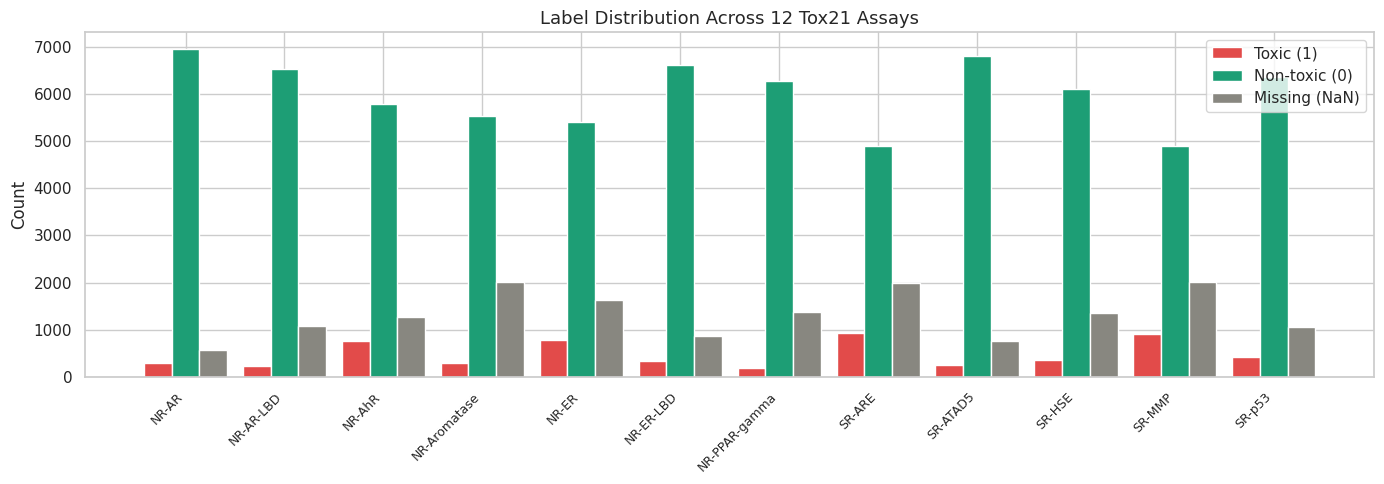

In [16]:
#Cell — Label distribution plot
toxic_counts    = tox21_df[assay_cols].apply(lambda x: (x == 1).sum())
nontoxic_counts = tox21_df[assay_cols].apply(lambda x: (x == 0).sum())
missing_counts  = tox21_df[assay_cols].isnull().sum()

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(assay_cols))
w = 0.28

ax.bar(x - w, toxic_counts,    width=w, label='Toxic (1)',     color='#E24B4A')
ax.bar(x,     nontoxic_counts, width=w, label='Non-toxic (0)', color='#1D9E75')
ax.bar(x + w, missing_counts,  width=w, label='Missing (NaN)', color='#888780')

ax.set_xticks(x)
ax.set_xticklabels(assay_cols, rotation=45, ha='right', fontsize=9)
ax.set_title('Label Distribution Across 12 Tox21 Assays', fontsize=13, fontweight='500')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('/content/label_distribution.png', dpi=150)
plt.show()

In [17]:
#Cell — Imbalance ratio
print("Toxic ratio per assay (toxic / total labeled):\n")
for col in assay_cols:
    labeled = tox21_df[col].dropna()
    ratio = labeled.sum() / len(labeled)
    print(f"  {col:<20} {ratio:.3f}  ({int(labeled.sum())} toxic / {len(labeled)} labeled)")

Toxic ratio per assay (toxic / total labeled):

  NR-AR                0.043  (309 toxic / 7265 labeled)
  NR-AR-LBD            0.035  (237 toxic / 6758 labeled)
  NR-AhR               0.117  (768 toxic / 6549 labeled)
  NR-Aromatase         0.052  (300 toxic / 5821 labeled)
  NR-ER                0.128  (793 toxic / 6193 labeled)
  NR-ER-LBD            0.050  (350 toxic / 6955 labeled)
  NR-PPAR-gamma        0.029  (186 toxic / 6450 labeled)
  SR-ARE               0.162  (942 toxic / 5832 labeled)
  SR-ATAD5             0.037  (264 toxic / 7072 labeled)
  SR-HSE               0.058  (372 toxic / 6467 labeled)
  SR-MMP               0.158  (918 toxic / 5810 labeled)
  SR-p53               0.062  (423 toxic / 6774 labeled)


In [18]:
#Cell — SMILES validation
def is_valid_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        return mol is not None
    except:
        return False

tox21_df['valid_mol'] = tox21_df['smiles'].apply(is_valid_smiles)
print(f"Valid SMILES:   {tox21_df['valid_mol'].sum()}")
print(f"Invalid SMILES: {(~tox21_df['valid_mol']).sum()}")

tox21_df = tox21_df[tox21_df['valid_mol']].drop(columns='valid_mol').reset_index(drop=True)
print(f"Remaining compounds: {len(tox21_df)}")

[11:34:08] WARNING: not removing hydrogen atom without neighbors
[11:34:08] Explicit valence for atom # 8 Al, 6, is greater than permitted
[11:34:08] Explicit valence for atom # 3 Al, 6, is greater than permitted
[11:34:08] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:34:08] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:34:08] Explicit valence for atom # 9 Al, 6, is greater than permitted
[11:34:08] Explicit valence for atom # 5 Al, 6, is greater than permitted
[11:34:09] Explicit valence for atom # 16 Al, 6, is greater than permitted
[11:34:09] Explicit valence for atom # 20 Al, 6, is greater than permitted


Valid SMILES:   7823
Invalid SMILES: 8
Remaining compounds: 7823


In [19]:
#Cell — Compute RDKit descriptors
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [np.nan] * 8
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol),
        rdMolDescriptors.CalcNumRings(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        Descriptors.FractionCSP3(mol),
    ]

desc_cols = ['MolWt','LogP','HBD','HBA','TPSA','NumRings','AromaticRings','FractionCSP3']
desc_df = pd.DataFrame(
    tox21_df['smiles'].apply(compute_descriptors).tolist(),
    columns=desc_cols
)
tox21_df = pd.concat([tox21_df.reset_index(drop=True), desc_df], axis=1)
print("Descriptors computed.")
tox21_df[desc_cols].describe().round(2)

[11:34:40] WARNING: not removing hydrogen atom without neighbors


Descriptors computed.


,MolWt,LogP,HBD,HBA,TPSA,NumRings,AromaticRings,FractionCSP3
count,7823.00,7823.00,7823.00,7823.00,7823.00,7823.00,7823.0,7823.00
mean,276.14,2.37,1.22,3.47,59.47,1.77,1.1,0.46
std,164.73,2.30,1.92,3.12,57.79,1.67,1.1,0.33
min,9.01,-17.41,0.00,0.00,0.00,0.00,0.0,0.00
25%,165.24,1.15,0.00,2.00,26.30,1.00,0.0,0.18
50%,240.30,2.37,1.00,3.00,46.53,1.00,1.0,0.42
75%,343.04,3.65,2.00,4.00,77.03,3.00,2.0,0.73
max,1877.66,22.61,30.00,46.00,777.98,30.00,12.0,1.00


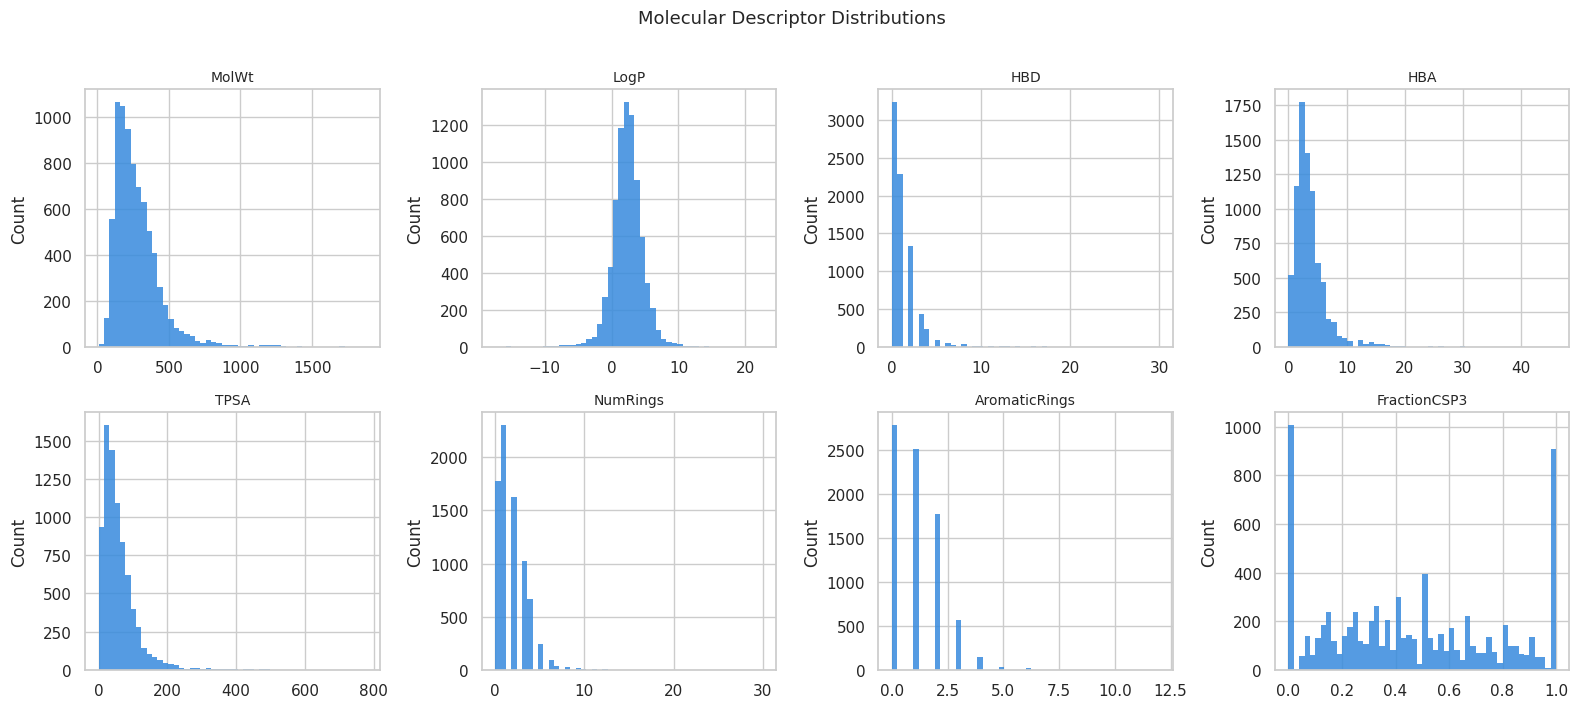

In [20]:
#Cell — Descriptor distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(desc_cols):
    axes[i].hist(tox21_df[col].dropna(), bins=50,
                 color='#378ADD', edgecolor='none', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='500')
    axes[i].set_ylabel('Count')

plt.suptitle('Molecular Descriptor Distributions', fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('/content/descriptor_distributions.png', dpi=150)
plt.show()

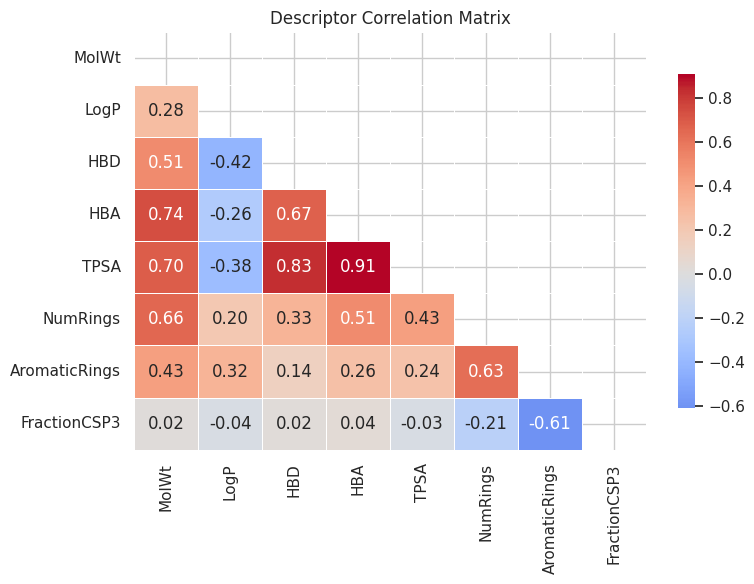

In [21]:
#Cell — Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = tox21_df[desc_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Descriptor Correlation Matrix', fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig('/content/descriptor_correlation.png', dpi=150)
plt.show()

In [22]:
#Cell — Load ZINC250k and extract features
zinc_df = pd.read_csv('/content/zinc250k/250k_rndm_zinc_drugs_clean_3.csv')
print("ZINC250k shape:", zinc_df.shape)
print("Columns:", list(zinc_df.columns))
zinc_df.head(3)

ZINC250k shape: (249455, 4)
Columns: ['smiles', 'logP', 'qed', 'SAS']


,smiles,logP,qed,SAS
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n,5.05060,0.702012,2.084095
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n,3.11370,0.928975,3.432004
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633


In [23]:
#Cell — Extract ZINC250k features via SMILES match
# Clean SMILES in ZINC (strip whitespace/newlines)
zinc_df['smiles'] = zinc_df['smiles'].str.strip()

# Compute same descriptors on ZINC to find overlap via InChIKey
from rdkit.Chem.inchi import MolToInchiKey

def get_inchikey(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return None
        return MolToInchiKey(mol)
    except:
        return None

print("Computing InChIKeys for Tox21...")
tox21_df['inchikey'] = tox21_df['smiles'].apply(get_inchikey)

print("Computing InChIKeys for ZINC250k (this takes ~2 min)...")
zinc_df['inchikey'] = zinc_df['smiles'].apply(get_inchikey)

# Merge on InChIKey
zinc_features = zinc_df[['inchikey','logP','qed','SAS']].dropna(subset=['inchikey'])
tox21_df = tox21_df.merge(zinc_features, on='inchikey', how='left')

matched = tox21_df['qed'].notna().sum()
print(f"\nMatched compounds: {matched} / {len(tox21_df)}")
print(f"Unmatched (will use NaN, filled below): {len(tox21_df) - matched}")

Computing InChIKeys for Tox21...


[11:38:09] WARNING: not removing hydrogen atom without neighbors


Computing InChIKeys for ZINC250k (this takes ~2 min)...

Matched compounds: 26 / 7823
Unmatched (will use NaN, filled below): 7797


In [24]:
#Cell — Fill unmatched ZINC features using RDKit
# For compounds not in ZINC, compute logP and QED directly via RDKit
from rdkit.Chem import QED

def rdkit_logp(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Descriptors.MolLogP(mol) if mol else np.nan

def rdkit_qed(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return QED.qed(mol) if mol else np.nan

mask = tox21_df['qed'].isna()
print(f"Filling {mask.sum()} compounds with RDKit-computed logP and QED...")

tox21_df.loc[mask, 'logP'] = tox21_df.loc[mask, 'smiles'].apply(rdkit_logp)
tox21_df.loc[mask, 'qed']  = tox21_df.loc[mask, 'smiles'].apply(rdkit_qed)
tox21_df.loc[mask, 'SAS']  = np.nan  # SAS needs sascorer, skip for now

print("Done. Null counts:")
print(tox21_df[['logP','qed','SAS']].isnull().sum())

Filling 7797 compounds with RDKit-computed logP and QED...


[11:44:33] WARNING: not removing hydrogen atom without neighbors
[11:44:37] WARNING: not removing hydrogen atom without neighbors
[11:44:37] WARNING: not removing hydrogen atom without neighbors


Done. Null counts:
logP       0
qed        0
SAS     7797
dtype: int64


In [25]:
#Cell — Morgan fingerprints
def smiles_to_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return np.zeros(n_bits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    return np.array(fp)

print("Computing Morgan fingerprints (ECFP4)...")
fp_matrix = np.vstack(tox21_df['smiles'].apply(smiles_to_fp).values)
print(f"Fingerprint matrix shape: {fp_matrix.shape}")

Computing Morgan fingerprints (ECFP4)...


Streaming output truncated to the last 5000 lines.
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:4

Fingerprint matrix shape: (7823, 2048)


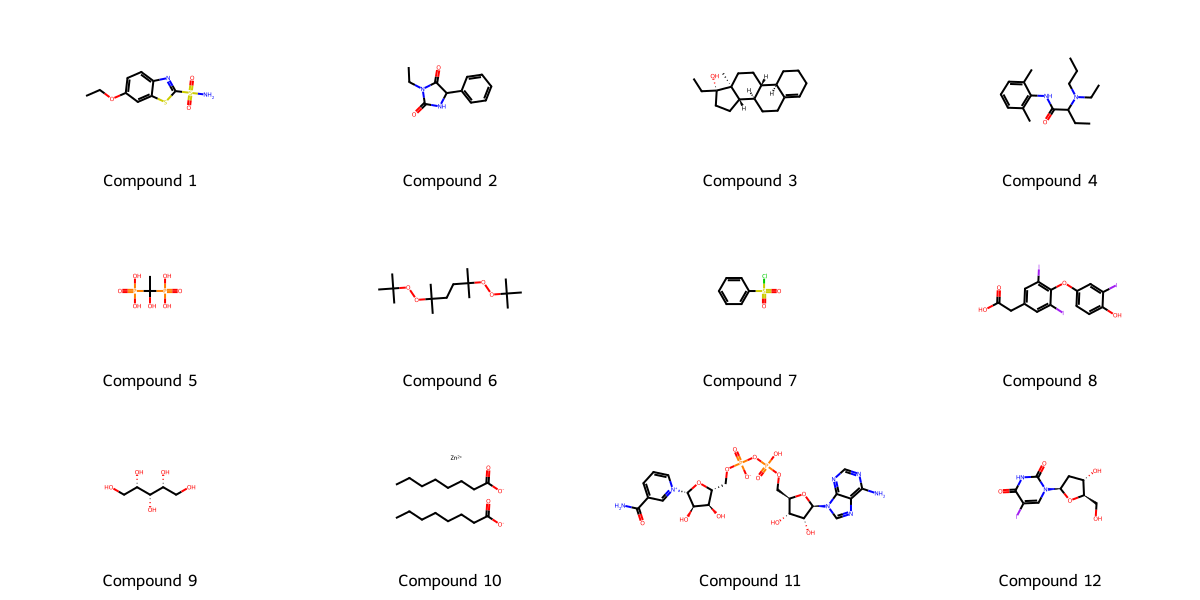

In [27]:
#Cell — Sample molecule visualization
from IPython.display import display
from PIL import Image
import io

sample_smiles = tox21_df['smiles'].iloc[:12].tolist()
mols = [Chem.MolFromSmiles(s) for s in sample_smiles]
mols = [m for m in mols if m is not None]

img = Draw.MolsToGridImage(
    mols[:12], molsPerRow=4, subImgSize=(300, 200),
    legends=[f"Compound {i+1}" for i in range(len(mols[:12]))],
    returnPNG=False
)

img.save('/content/sample_molecules.png')
display(img)

In [29]:
#Cell — Save everything
import os
os.makedirs('/content/processed', exist_ok=True)

tox21_df.to_csv('/content/processed/tox21_processed.csv', index=False)
np.save('/content/processed/fp_matrix.npy', fp_matrix)

# Save final feature column list for use in nb02
feature_cols = desc_cols + ['logP', 'qed']
pd.Series(feature_cols).to_csv('/content/processed/feature_cols.csv', index=False)

print("Saved:")
print("  /content/processed/tox21_processed.csv")
print("  /content/processed/fp_matrix.npy")
print("  /content/processed/feature_cols.csv")
print(f"\nFinal dataset: {len(tox21_df)} compounds")
print(f"Feature columns: {feature_cols}")
print(f"Fingerprint matrix: {fp_matrix.shape}")

Saved:
  /content/processed/tox21_processed.csv
  /content/processed/fp_matrix.npy
  /content/processed/feature_cols.csv

Final dataset: 7823 compounds
Feature columns: ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA', 'NumRings', 'AromaticRings', 'FractionCSP3', 'logP', 'qed']
Fingerprint matrix: (7823, 2048)


In [30]:
print("Compound count:", len(tox21_df))
print("Matched ZINC:", tox21_df['qed'].notna().sum())
print("FP matrix shape:", fp_matrix.shape)
print("Feature cols:", pd.read_csv('/content/processed/feature_cols.csv')['0'].tolist())

Compound count: 7823
Matched ZINC: 7823
FP matrix shape: (7823, 2048)
Feature cols: ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA', 'NumRings', 'AromaticRings', 'FractionCSP3', 'logP', 'qed']
